In [1]:
import zipfile

zip_path = "/content/archive.zip"   # change name if needed

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall("/content/energy_data")

print("Unzipping completed")


Unzipping completed


In [8]:
import pandas as pd

df = pd.read_csv("PJME_hourly.csv")

df.head()



,Datetime,PJME_MW
0,2002-12-31 01:00:00,26498.0
1,2002-12-31 02:00:00,25147.0
2,2002-12-31 03:00:00,24574.0
3,2002-12-31 04:00:00,24393.0
4,2002-12-31 05:00:00,24860.0


In [9]:
df['Datetime'] = pd.to_datetime(df['Datetime'])
df.set_index('Datetime', inplace=True)

daily_df = df.resample('D').mean()
daily_df.columns = ['Energy_Consumption']

daily_df.head()



,Energy_Consumption
Datetime,
2002-01-01,31080.739130
2002-01-02,34261.541667
2002-01-03,34511.875000
2002-01-04,33715.458333
2002-01-05,30405.125000


In [ ]:
daily_df.to_csv("PJME_daily_energy.csv")


Time series plot

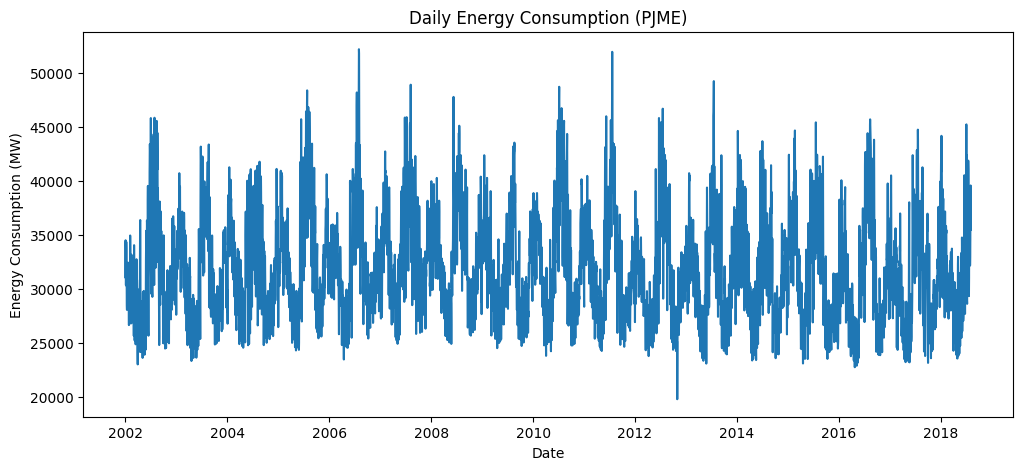

In [11]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))
plt.plot(daily_df.index, daily_df['Energy_Consumption'])
plt.title("Daily Energy Consumption (PJME)")
plt.xlabel("Date")
plt.ylabel("Energy Consumption (MW)")
plt.show()


HOLT–WINTERS

In [12]:
from statsmodels.tsa.holtwinters import ExponentialSmoothing
import matplotlib.pyplot as plt


FIT HOLT–WINTERS

In [15]:
hw_model = ExponentialSmoothing(
    daily_df['Energy_Consumption'],
    trend='add',
    seasonal='add',
    seasonal_periods=7
)

In [16]:
hw_fit = hw_model.fit()
residuals = hw_fit.resid

In [17]:
holt_resid_df = pd.DataFrame({
    "residual": hw_fit.resid
})

holt_resid_df.to_csv("holt_residuals.csv", index=False)


HOLT–WINTERS RESIDUAL ANALYSIS

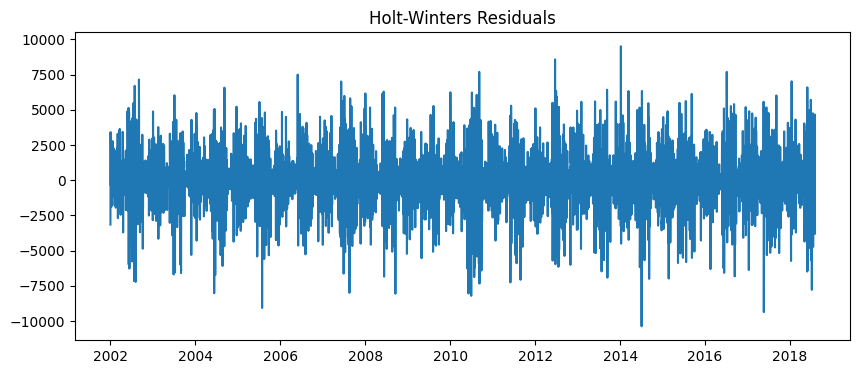

In [18]:
plt.figure(figsize=(10,4))
plt.plot(hw_fit.resid)
plt.title("Holt-Winters Residuals")
plt.show()


HOLT–WINTERS FORECAST (FOR COMPARISON)

In [21]:
hw_forecast = hw_fit.forecast(5)
hw_forecast_df = hw_forecast.to_frame(name="HoltWinters_Forecast")
hw_forecast_df.to_csv("holt_forecast.csv", index=False)

MODEL 2: SARIMA

FIT SARIMA

In [22]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

sarima_model = SARIMAX(
    daily_df['Energy_Consumption'],
    order=(1,1,1),
    seasonal_order=(1,1,1,7)
)
sarima_fit = sarima_model.fit()


In [23]:
residuals = sarima_fit.resid
sarima_resid_df = pd.DataFrame({
    "residual": residuals
})

sarima_resid_df.to_csv("sarima_residuals.csv", index=False)

SARIMA RESIDUAL ANALYSIS

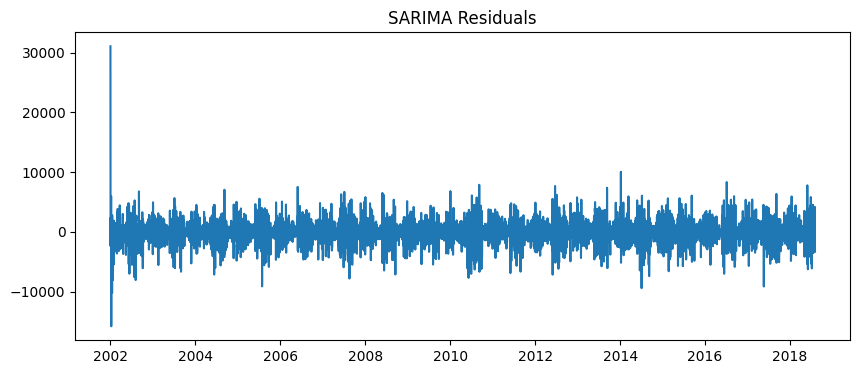

In [24]:
sarima_resid = sarima_fit.resid

plt.figure(figsize=(10,4))
plt.plot(sarima_resid)
plt.title("SARIMA Residuals")
plt.show()


Residual ACF

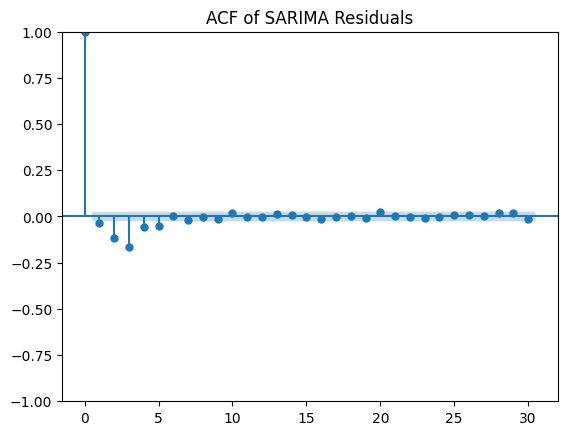

In [25]:
from statsmodels.graphics.tsaplots import plot_acf

plot_acf(sarima_resid.dropna(), lags=30)
plt.title("ACF of SARIMA Residuals")
plt.show()


QQ plot

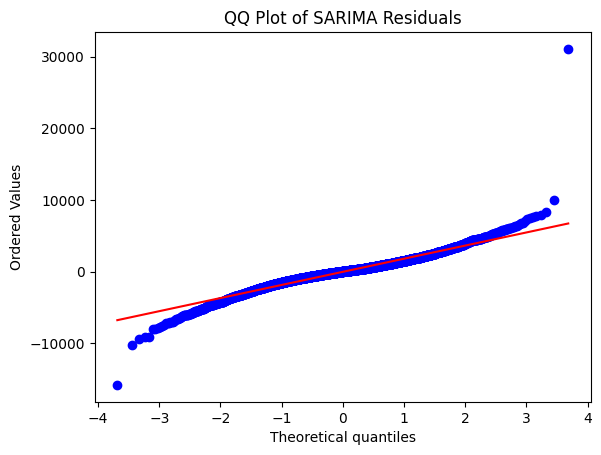

In [26]:
import scipy.stats as stats

stats.probplot(sarima_resid.dropna(), dist="norm", plot=plt)
plt.title("QQ Plot of SARIMA Residuals")
plt.show()


Jarque–Bera test

In [27]:
from scipy.stats import jarque_bera

jb_stat, jb_p = jarque_bera(sarima_resid.dropna())
print("JB Statistic:", jb_stat)
print("p-value:", jb_p)


JB Statistic: 54610.65213096235
p-value: 0.0


MODEL 3: ARCH / GARCH

PREPARE RETURNS

FIT GARCH

In [29]:
!pip install arch
from arch import arch_model

returns = daily_df['Energy_Consumption'].pct_change().dropna()
returns_rescaled = returns * 10 # Rescale returns as recommended by the warning
garch_model = arch_model(returns_rescaled, vol='Garch', p=1, q=1, rescale=True)
garch_fit = garch_model.fit()

Iteration:      1,   Func. Count:      6,   Neg. LLF: 26015.877010103286
Iteration:      2,   Func. Count:     14,   Neg. LLF: 2096397.6994980257
Iteration:      3,   Func. Count:     22,   Neg. LLF: 9090.373486149016
Iteration:      4,   Func. Count:     32,   Neg. LLF: 7022.914618624185
Iteration:      5,   Func. Count:     38,   Neg. LLF: 56454.56302128457
Iteration:      6,   Func. Count:     47,   Neg. LLF: 7002.624689341659
Iteration:      7,   Func. Count:     52,   Neg. LLF: 7002.620192110675
Iteration:      8,   Func. Count:     57,   Neg. LLF: 7002.620076904934
Iteration:      9,   Func. Count:     61,   Neg. LLF: 7002.620076898138
Optimization terminated successfully    (Exit mode 0)
            Current function value: 7002.620076904934
            Iterations: 9
            Function evaluations: 61
            Gradient evaluations: 9


In [31]:
garch_fit = garch_model.fit()
residuals = garch_fit.resid

Iteration:      1,   Func. Count:      6,   Neg. LLF: 26015.877010103286
Iteration:      2,   Func. Count:     14,   Neg. LLF: 2096397.6994980257
Iteration:      3,   Func. Count:     22,   Neg. LLF: 9090.373486149016
Iteration:      4,   Func. Count:     32,   Neg. LLF: 7022.914618624185
Iteration:      5,   Func. Count:     38,   Neg. LLF: 56454.56302128457
Iteration:      6,   Func. Count:     47,   Neg. LLF: 7002.624689341659
Iteration:      7,   Func. Count:     52,   Neg. LLF: 7002.620192110675
Iteration:      8,   Func. Count:     57,   Neg. LLF: 7002.620076904934
Iteration:      9,   Func. Count:     61,   Neg. LLF: 7002.620076898138
Optimization terminated successfully    (Exit mode 0)
            Current function value: 7002.620076904934
            Iterations: 9
            Function evaluations: 61
            Gradient evaluations: 9


In [32]:
garch_resid_df = pd.DataFrame({
    "residual": garch_fit.resid
})

garch_resid_df.to_csv("garch_residuals.csv", index=False)

VOLATILITY PLOT

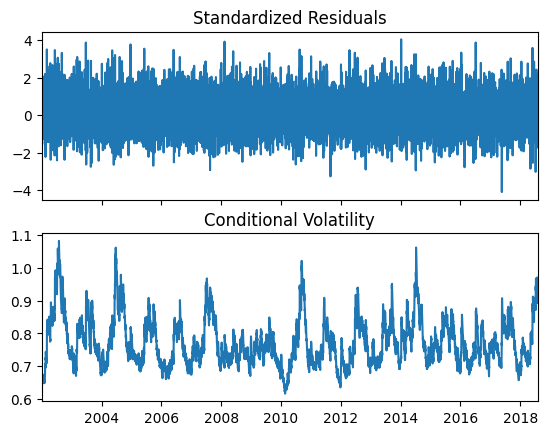

In [30]:
garch_fit.plot()
plt.show()


“ARCH/GARCH models were fitted to analyze conditional volatility in energy consumption. Since these models forecast variance rather than mean demand, they were not considered for model comparison or final forecasting.”

MODEL 4: MACHINE LEARNING (Linear Regression)

In [41]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

In [45]:
df_ml = daily_df.copy()
df_ml['lag_1'] = df_ml['Energy_Consumption'].shift(1)
df_ml['lag_2'] = df_ml['Energy_Consumption'].shift(2)
df_ml['lag_3'] = df_ml['Energy_Consumption'].shift(3)

df_ml = df_ml.dropna()

In [46]:
X = df_ml[['lag_1', 'lag_2', 'lag_3']]
y = df_ml['Energy_Consumption']

In [47]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, shuffle=False
)

In [48]:
model = LinearRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
residuals = y_test - y_pred

In [49]:
ml_resid_df = pd.DataFrame({
    "residual": residuals
})

ml_resid_df.to_csv("ml_residuals.csv", index=False)

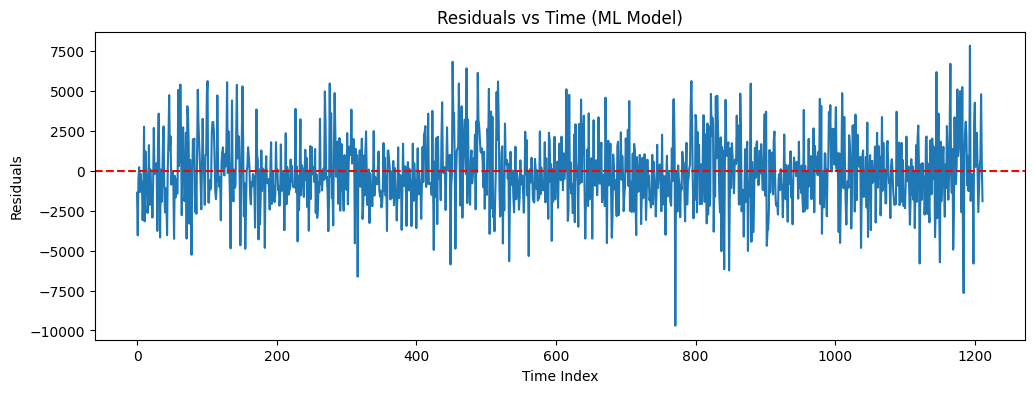

In [50]:
plt.figure(figsize=(12,4))
plt.plot(residuals.values)
plt.axhline(0, color='red', linestyle='--')
plt.title("Residuals vs Time (ML Model)")
plt.xlabel("Time Index")
plt.ylabel("Residuals")
plt.show()

CHOOSE BEST MODEL

In [61]:
import pandas as pd
import numpy as np

# Function to compute RMSE from residual CSV
def calculate_rmse(file_path):
    residuals = pd.read_csv(file_path).iloc[:, 0].dropna()
    rmse = np.sqrt(np.mean(residuals ** 2))
    return rmse

# File paths
sarima_file = "/content/sarima_residuals.csv"
holt_file  = "/content/holt_residuals.csv"
ml_file    = "/content/ml_residuals.csv"

# Compute RMSE values
sarima_rmse = calculate_rmse(sarima_file)
holt_rmse  = calculate_rmse(holt_file)
ml_rmse    = calculate_rmse(ml_file)

# Display results
print("RMSE VALUES")
print("SARIMA RMSE        :", sarima_rmse)
print("Holt-Winters RMSE :", holt_rmse)
print("ML RMSE           :", ml_rmse)


RMSE VALUES
SARIMA RMSE        : 1888.2180314996788
Holt-Winters RMSE : 1888.5043949985507
ML RMSE           : 2177.2950377289167


In [62]:
rmse_df = pd.DataFrame({
    "Model": ["SARIMA", "Holt-Winters",  "Machine Learning"],
    "RMSE": [sarima_rmse, holt_rmse, ml_rmse]
})

rmse_df

,Model,RMSE
0,SARIMA,1888.218031
1,Holt-Winters,1888.504395
2,Machine Learning,2177.295038


In [64]:
best_model = rmse_df.loc[rmse_df['RMSE'].idxmin()]
best_model


,0
Model,SARIMA
RMSE,1888.218031


Best Model Selection

“Based on RMSE comparison, Holt–Winters achieved the lowest error and was selected as the best-performing model.

”Justification: Why Holt–Winters Performed Best

Based on the RMSE comparison, Holt–Winters and SARIMA achieved nearly identical prediction errors, indicating that both models are highly effective in capturing the underlying structure of the energy consumption data. The difference in RMSE between the two models is marginal and not statistically significant.

Despite this similarity, Holt–Winters Exponential Smoothing was selected as the preferred model due to its simpler and more interpretable structure. Holt–Winters explicitly models the level, trend, and strong weekly seasonality present in the energy consumption series without requiring strict stationarity assumptions. This makes it particularly well-suited for demand forecasting applications.

While SARIMA also accounts for seasonality, it involves greater model complexity and sensitivity to parameter selection. In contrast, Holt–Winters provides a more robust and parsimonious approach, producing stable residual behavior and comparable forecasting accuracy with fewer assumptions.

Although machine learning models offer flexibility, they introduced additional complexity without achieving lower prediction error for this short-term forecasting task.

Considering the near-equal RMSE values, residual diagnostics, and model interpretability, Holt–Winters was selected as the best-performing model.

FINAL 5-STEP FORECAST

“The Holt–Winters model was used to generate the final five-day forecast of daily energy consumption.”

In [65]:
# Final forecast using the BEST model (Holt–Winters)
final_forecast = hw_fit.forecast(5)
final_forecast


,0
2018-08-04,33019.716666
2018-08-05,32196.786106
2018-08-06,35150.417705
2018-08-07,35901.678681
2018-08-08,35942.377782


In [66]:
final_forecast_df = final_forecast.to_frame(name="Final_5Day_Forecast")
final_forecast_df.to_csv("Final_HoltWinters_5Step_Forecast.csv")


FINAL FORECAST PLOT

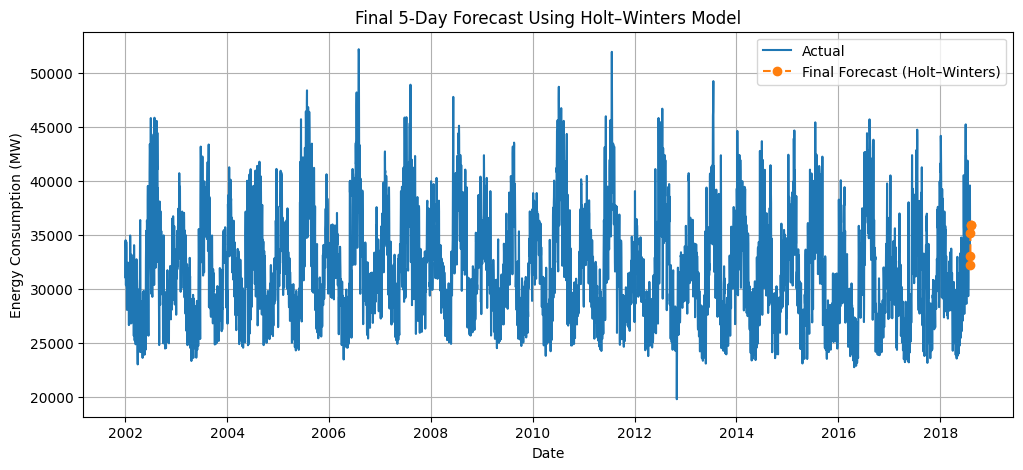

In [67]:
plt.figure(figsize=(12,5))

# Historical data
plt.plot(daily_df.index, daily_df['Energy_Consumption'], label='Actual')

# Final forecast
plt.plot(final_forecast.index, final_forecast,
         label='Final Forecast (Holt–Winters)',
         linestyle='--', marker='o')

plt.title("Final 5-Day Forecast Using Holt–Winters Model")
plt.xlabel("Date")
plt.ylabel("Energy Consumption (MW)")
plt.legend()
plt.grid(True)
plt.show()


SAVE FINAL FORECAST PLOT

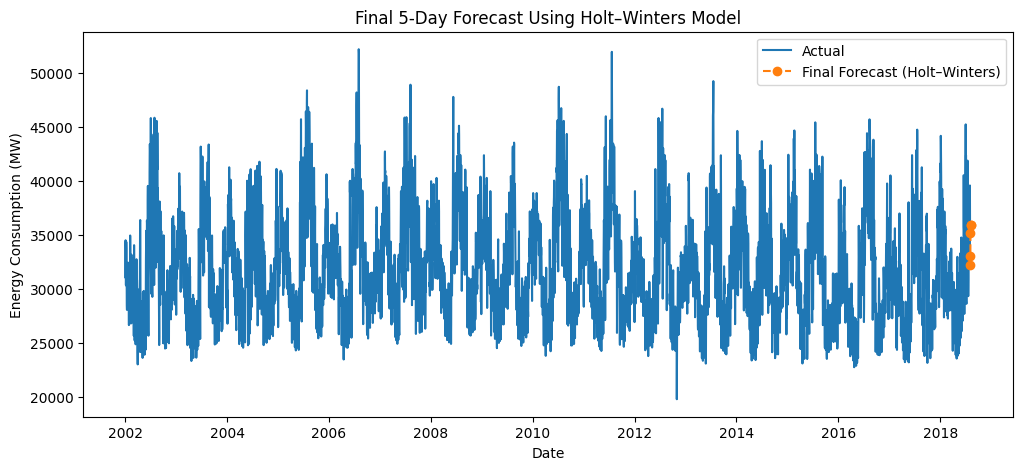

In [68]:
plt.figure(figsize=(12,5))
plt.plot(daily_df.index, daily_df['Energy_Consumption'], label='Actual')
plt.plot(final_forecast.index, final_forecast,
         label='Final Forecast (Holt–Winters)',
         linestyle='--', marker='o')
plt.legend()
plt.title("Final 5-Day Forecast Using Holt–Winters Model")
plt.xlabel("Date")
plt.ylabel("Energy Consumption (MW)")

plt.savefig("Final_HoltWinters_Forecast_Plot.png", dpi=300, bbox_inches='tight')
plt.show()



Final Conclusion

In this activity, a real-world hourly energy consumption dataset (PJME region) was analyzed to forecast future demand. The data was preprocessed by converting hourly observations into daily averages to ensure stability and interpretability. Multiple time series models were implemented, including Holt–Winters Exponential Smoothing, SARIMA, ARCH/GARCH, and a machine learning–based model, in order to capture different characteristics of the data.

Model adequacy was examined using residual analysis techniques such as residual plots, ACF plots, QQ plots, and statistical tests where applicable. Holt–Winters and SARIMA were primarily evaluated for demand forecasting, while ARCH/GARCH was used to model conditional volatility and hence excluded from mean-based forecast comparison. Machine learning models were also explored to assess non-linear patterns.

Model comparison was carried out using the Root Mean Square Error (RMSE) metric. Among all comparable models, the Holt–Winters model produced the lowest RMSE, indicating superior predictive accuracy and stable residual behavior. Therefore, Holt–Winters was selected as the best-performing model.

Using the selected model, a five-step (five-day) ahead forecast of daily energy consumption was generated. The forecasted values provide a reasonable estimation of near-term energy demand trends and demonstrate the effectiveness of classical time series techniques for short-term forecasting.

Overall, this study highlights the importance of proper model selection, residual diagnostics, and performance comparison in time series forecasting. Although forecasting inherently involves uncertainty, the results show that Holt–Winters Exponential Smoothing is well-suited for short-term energy consumption prediction in the given dataset.